# 1.11 EIP-8279 Runtime BAL Meter and Demand Coupling

This notebook reconstructs the per-transaction runtime byte counter specified by [EIP-8279](https://eips.ethereum.org/EIPS/eip-8279) and uses it as the BAL quantity in the fee model.

The analysis has three tasks:

1. reconstruct and attribute the runtime counter from transaction-level protocol events for the full 6,000-block Xatu panel;
2. split metered BAL bytes into a state-linked component and an execution-linked component; and
3. define the central aggregate BAL model used by the independent-resource equilibrium calculation.

The execution-linked label denotes the remaining access-related runtime BAL represented by an execution-activity proxy; it does not claim that execution gas mechanically causes every byte. Transaction-cost exposure is retained only as an appendix diagnostic on the cached 1,200-block transaction panel.

In [1]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from sim.xatu_bal_8279 import (
    attribute_direct_state_runtime_bytes,
    attach_normalized_composite_costs,
)

START_DATE = '2026-02-01'
END_DATE = '2026-06-01'
DATE_TAG = f'{START_DATE}_{END_DATE}'
DATA_DIR = ROOT / 'data'
PLOT_DIR = ROOT / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TX_RUNTIME_CSV = DATA_DIR / f'calibration_xatu_bal_runtime_8279_transactions_{DATE_TAG}.csv'
TX_GAS_INPUTS_CSV = DATA_DIR / f'calibration_xatu_bal_runtime_8279_transaction_gas_inputs_{DATE_TAG}.csv'
BLOCK_RUNTIME_CSV = DATA_DIR / f'calibration_xatu_bal_runtime_8279_blocks_{DATE_TAG}.csv'
STATE_EXECUTION_BLOCK_CSV = DATA_DIR / f'calibration_xatu_bal_runtime_8279_state_execution_blocks_{DATE_TAG}.csv'
BAL_PHYSICAL_BLOCK_CSV = DATA_DIR / f'calibration_bal_block_predictions_{DATE_TAG}.csv'
DAILY_ACCOUNTING_CSV = DATA_DIR / f'daily_accounting_panel_calibrated_with_bal_{DATE_TAG}.csv'
OUT_DAILY_CSV = DATA_DIR / f'calibration_bal_runtime_8279_daily_{DATE_TAG}.csv'
OUT_COMPONENTS_CSV = DATA_DIR / f'bal_runtime_8279_component_attribution_{DATE_TAG}.csv'
OUT_TWO_WAY_CSV = DATA_DIR / f'bal_runtime_8279_two_way_decomposition_{DATE_TAG}.csv'
OUT_EXPOSURE_CSV = DATA_DIR / f'bal_runtime_8279_composite_cost_exposure_{DATE_TAG}.csv'
OUT_PHYSICAL_COMPARISON_CSV = DATA_DIR / f'bal_runtime_8279_physical_comparison_{DATE_TAG}.csv'
OUT_CARD_CSV = DATA_DIR / f'bal_runtime_8279_parameter_card_{DATE_TAG}.csv'
COUPLING_PLOT = PLOT_DIR / f'bal_state_creation_coupling_calibration_{DATE_TAG}.png'
DATA_COMPONENT_PLOT = PLOT_DIR / f'daily_data_resource_components_runtime_8279_{DATE_TAG}.png'

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
})


## Reconstructing the runtime counter

The EIP-8279 runtime counter is a deterministic weighted sum of protocol events. Xatu exposes the required cold account accesses, cold storage-key accesses, changed storage values, value-bearing calls and self-destructs, internal creations, creation endowments, and deployed code bytes. The block-level estimator is

$$
\begin{aligned}
\widehat M_i={}&
20N_{\mathrm{cold\ account},i}
+32N_{\mathrm{cold\ storage},i}
+32N_{\mathrm{changed\ value},i} \\
&+32N_{\mathrm{value\ call},i}
+32N_{\mathrm{selfdestruct},i}
+28N_{\mathrm{create},i} \\
&+32N_{\mathrm{endowed\ create},i}
+\mathrm{codeBytes}_i.
\end{aligned}
$$

Each internal `CREATE` or `CREATE2` counted by the runtime meter adds 28 bytes: 20 bytes for the new contract address and 8 bytes for its nonce. If the creation also transfers ETH to the new contract, the meter adds another 32 bytes for the contract's initial balance.

The protocol-event reconstruction and the state/execution attribution are both run transaction by transaction over all 6,000 sampled blocks. The transaction sums are required to reproduce the independent block-level runtime reconstruction exactly. The cached 1,200-block transaction panel is retained only for the transaction-cost diagnostic.

Xatu records cold accesses and value-bearing calls even when the surrounding call later reverts, so those EIP-8279 bytes are included. Storage writes are different: Xatu's storage-diff table contains only changes that remain after the transaction finishes. If a reverted call temporarily changes a storage value, EIP-8279 retains the 32-byte meter charge, but Xatu contains no final storage diff from which to recover it. The reconstruction therefore misses these specific reverted storage-value charges and may slightly understate the runtime counter.

The 51-byte static allowance per EIP-7702 authorization and entries covered by transaction-base headroom are not part of `bal_data_bytes` and are excluded.

In [2]:
required = [
    TX_RUNTIME_CSV, TX_GAS_INPUTS_CSV, BLOCK_RUNTIME_CSV,
    STATE_EXECUTION_BLOCK_CSV, BAL_PHYSICAL_BLOCK_CSV, DAILY_ACCOUNTING_CSV,
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Missing cached inputs:\n' + '\n'.join(missing))

# The cached transaction panel is retained for the cost-exposure appendix.
tx_runtime_raw = pd.read_csv(TX_RUNTIME_CSV)
tx_gas_inputs = pd.read_csv(TX_GAS_INPUTS_CSV)
runtime_blocks = pd.read_csv(BLOCK_RUNTIME_CSV)
attribution_blocks = pd.read_csv(STATE_EXECUTION_BLOCK_CSV)
bal_physical_blocks = pd.read_csv(BAL_PHYSICAL_BLOCK_CSV)
daily_accounting = pd.read_csv(DAILY_ACCOUNTING_CSV)

tx_runtime = attribute_direct_state_runtime_bytes(tx_runtime_raw)
tx_cost_panel = attach_normalized_composite_costs(tx_runtime, tx_gas_inputs)

assert tx_runtime['block_number'].nunique() == 1_200
assert len(tx_runtime) == 382_867
assert runtime_blocks['block_number'].nunique() == 6_000
assert attribution_blocks['block_number'].nunique() == 6_000
assert len(runtime_blocks) == len(attribution_blocks) == 6_000
assert len(tx_cost_panel) == len(tx_runtime)
assert (
    attribution_blocks['bal_runtime_bytes_state_8279']
    + attribution_blocks['bal_runtime_bytes_execution_8279']
    == attribution_blocks['bal_runtime_bytes_8279']
).all()

validation = runtime_blocks[['block_number', 'bal_runtime_bytes_8279']].merge(
    attribution_blocks[['block_number', 'bal_runtime_bytes_8279']],
    on='block_number', how='inner', validate='one_to_one',
    suffixes=('_block', '_transaction'),
)
validation['difference'] = (
    validation['bal_runtime_bytes_8279_block']
    - validation['bal_runtime_bytes_8279_transaction']
)
assert len(validation) == 6_000
assert validation['difference'].eq(0).all()
validation_summary = pd.DataFrame([{
    'validation_blocks': len(validation),
    'exact_matches': int(validation['difference'].eq(0).sum()),
    'mean_absolute_difference_bytes': validation['difference'].abs().mean(),
}])
validation_summary

,validation_blocks,exact_matches,mean_absolute_difference_bytes
0,6000,6000,0.0


In [3]:
daily = (
    runtime_blocks.groupby('date', as_index=False)
    .agg(
        panel_blocks=('block_number', 'size'),
        bal_runtime_bytes_per_block_8279=('bal_runtime_bytes_8279', 'mean'),
    )
).merge(daily_accounting, on='date', how='left', validate='one_to_one')
daily.to_csv(OUT_DAILY_CSV, index=False)

RUNTIME_ANCHOR = np.average(
    daily['bal_runtime_bytes_per_block_8279'], weights=daily['block_count']
)
RUNTIME_DATA_GAS_16 = 16 * RUNTIME_ANCHOR
pd.DataFrame([{
    'direct_xatu_blocks': len(runtime_blocks),
    'runtime_meter_bytes_per_block': RUNTIME_ANCHOR,
    'runtime_data_gas_per_block_at_16': RUNTIME_DATA_GAS_16,
}])


,direct_xatu_blocks,runtime_meter_bytes_per_block,runtime_data_gas_per_block_at_16
0,6000,119943.743249,1.919100e+06


## Runtime-metered BAL versus final BAL RLP size

The EIP-8279 counter is the quantity priced by the data fee, but it is not the final BAL object propagated with the block. We compare both quantities on the 1,200 deterministic blocks for which exact final BAL RLP sizes are cached. This comparison is a capacity diagnostic only; the demand model continues to use runtime-metered bytes.

For the matched sample, final BAL RLP averages **134,087 bytes per block**, while the runtime counter averages **121,006 bytes**. The difference is therefore **13,080 bytes**, or **0.0131 MB**, per block. Final BAL RLP is 1.1081 times the runtime counter, but the capacity adjustment uses only the difference between them.

If $D_{\mathrm{metered}}$ includes the EIP-8279 BAL counter, then the BAL-adjusted content size is

$$
D_{\mathrm{BAL\ adjusted}}
=D_{\mathrm{metered}}-B_{\mathrm{runtime}}+B_{\mathrm{RLP}}.
$$

A 90M data-gas limit represents 5,625,000 metered-byte units, or 5.625 MB. If BAL stayed at the matched sample mean, replacing its 0.1210 MB runtime count with its 0.1341 MB final RLP would give **5.638 MB** of BAL-adjusted content. Adding the entire 0.1341 MB BAL RLP to 5.625 MB would double-count the 0.1210 MB runtime BAL already included in the metered total. The result is still not a full physical block-size bound because complete transaction envelopes and other protocol framing are excluded.


In [4]:
exact_bal_comparison = (
    bal_physical_blocks.loc[
        bal_physical_blocks['bal_source'].eq('observed_rpc'),
        ['date', 'block_number', 'bal_rlp_bytes_observed'],
    ]
    .merge(
        runtime_blocks[['block_number', 'bal_runtime_bytes_8279']],
        on='block_number', how='inner', validate='one_to_one',
    )
)
assert len(exact_bal_comparison) == 1_200
assert exact_bal_comparison['bal_rlp_bytes_observed'].notna().all()
assert exact_bal_comparison['bal_runtime_bytes_8279'].gt(0).all()

BAL_RLP_BYTES_PER_BLOCK = exact_bal_comparison['bal_rlp_bytes_observed'].mean()
BAL_RUNTIME_BYTES_PER_BLOCK = exact_bal_comparison['bal_runtime_bytes_8279'].mean()
BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK = (
    BAL_RLP_BYTES_PER_BLOCK - BAL_RUNTIME_BYTES_PER_BLOCK
)
BAL_PHYSICAL_TO_RUNTIME_RATIO = (
    exact_bal_comparison['bal_rlp_bytes_observed'].sum()
    / exact_bal_comparison['bal_runtime_bytes_8279'].sum()
)
DATA_GAS_LIMIT_EXAMPLE = 90_000_000
METERED_BYTE_CAP_EXAMPLE = DATA_GAS_LIMIT_EXAMPLE / 16
BAL_ADJUSTED_BYTE_CAP_AT_SAMPLE_MEAN = (
    METERED_BYTE_CAP_EXAMPLE + BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK
)

physical_comparison = pd.DataFrame([{
    'matched_blocks': len(exact_bal_comparison),
    'bal_rlp_bytes_per_block': BAL_RLP_BYTES_PER_BLOCK,
    'bal_runtime_bytes_8279_per_block': BAL_RUNTIME_BYTES_PER_BLOCK,
    'bal_rlp_minus_runtime_bytes_per_block': BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK,
    'bal_rlp_minus_runtime_mb_per_block': BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK / 1e6,
    'bal_rlp_to_runtime_ratio': BAL_PHYSICAL_TO_RUNTIME_RATIO,
    'runtime_to_bal_rlp_ratio': 1 / BAL_PHYSICAL_TO_RUNTIME_RATIO,
    'metered_byte_units_at_90m_data_gas': METERED_BYTE_CAP_EXAMPLE,
    'bal_adjusted_content_mb_at_90m_sample_mean_bal': (
        BAL_ADJUSTED_BYTE_CAP_AT_SAMPLE_MEAN / 1e6
    ),
}])
physical_comparison.to_csv(OUT_PHYSICAL_COMPARISON_CSV, index=False)
physical_comparison.T


,0
matched_blocks,1.200000e+03
bal_rlp_bytes_per_block,1.340865e+05
bal_runtime_bytes_8279_per_block,1.210061e+05
bal_rlp_minus_runtime_bytes_per_block,1.308041e+04
bal_rlp_minus_runtime_mb_per_block,1.308041e-02
bal_rlp_to_runtime_ratio,1.108097e+00
runtime_to_bal_rlp_ratio,9.024480e-01
metered_byte_units_at_90m_data_gas,5.625000e+06
bal_adjusted_content_mb_at_90m_sample_mean_bal,5.638080e+00


## Daily data-resource content

The daily accounting view combines static transaction content with the direct EIP-8279 runtime reconstruction. It is descriptive only: the BAL series remains behaviorally distinct from static data in the demand model.


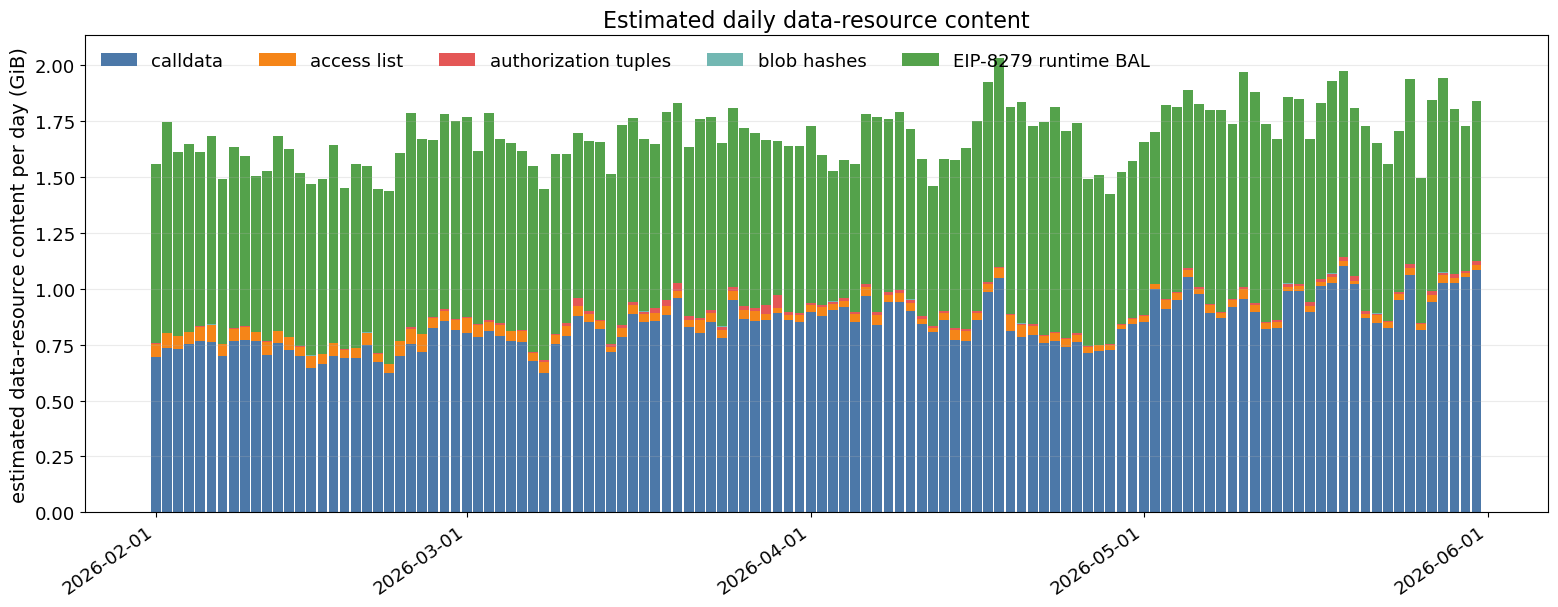

In [5]:
daily_content = daily_accounting[[
    'date', 'block_count', 'calldata_bytes', 'cal_tx_access_list_bytes',
    'cal_authorization_tuple_8131_bytes', 'blob_versioned_hash_bytes',
]].merge(
    daily[['date', 'bal_runtime_bytes_per_block_8279']],
    on='date', how='left', validate='one_to_one',
)
daily_content['runtime_bal_bytes'] = (
    daily_content['bal_runtime_bytes_per_block_8279'] * daily_content['block_count']
)
daily_content['date'] = pd.to_datetime(daily_content['date'])
component_columns = [
    'calldata_bytes', 'cal_tx_access_list_bytes',
    'cal_authorization_tuple_8131_bytes', 'blob_versioned_hash_bytes',
    'runtime_bal_bytes',
]
component_labels = [
    'calldata', 'access list', 'authorization tuples', 'blob hashes',
    'EIP-8279 runtime BAL',
]
component_colors = ['#4c78a8', '#f58518', '#e45756', '#72b7b2', '#54a24b']
fig, ax = plt.subplots(figsize=(15.8, 6.3))
bottom = np.zeros(len(daily_content))
for column, label, color in zip(component_columns, component_labels, component_colors):
    values = daily_content[column].to_numpy(dtype=float) / 2**30
    ax.bar(daily_content['date'], values, bottom=bottom, width=0.88, color=color, label=label)
    bottom += values
ax.set_ylabel('estimated data-resource content per day (GiB)')
ax.set_title('Estimated daily data-resource content')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(frameon=False, ncol=5, loc='upper left')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(DATA_COMPONENT_PLOT, dpi=220, bbox_inches='tight')
plt.show()


## State- and execution-linked runtime BAL

The full 6,000-block transaction panel is used to separate the runtime meter into two components:

$$
M_{\mathrm{BAL}}=M_{\mathrm{state}}+M_{\mathrm{execution}}.
$$

- $M_{\mathrm{state}}$ contains runtime bytes matched directly to new storage slots, new accounts, or deployed code.
- $M_{\mathrm{execution}}$ contains the remaining runtime bytes, including existing-state access and other EIP-8279 events not matched directly to persistent state creation.

New storage slots are matched to cold storage-key and changed-value events. New accounts are matched to creation, cold-account, and value-transfer events. Deployed code is matched directly to runtime code bytes. Xatu's aggregated structlogs do not preserve the target address or storage key for each cold-access count, so cold key, account, and balance matches are capped within each transaction. The state-linked result is therefore a reproducible matched estimate rather than exact address-level attribution.

The execution suffix is model notation for the second component because total execution is used as its activity proxy. It does not mean that every byte in $M_{\mathrm{execution}}$ is mechanically generated by execution gas.

In [6]:
daily_attribution = (
    attribution_blocks.groupby('date', as_index=False)
    .agg(
        runtime_bytes=('bal_runtime_bytes_8279', 'sum'),
        state_bytes=('bal_runtime_bytes_state_8279', 'sum'),
        execution_bytes=('bal_runtime_bytes_execution_8279', 'sum'),
        sampled_blocks=('block_number', 'size'),
    )
)
daily_attribution['state_weight'] = (
    daily_attribution['state_bytes'] / daily_attribution['runtime_bytes']
)
daily_attribution['execution_weight'] = (
    daily_attribution['execution_bytes'] / daily_attribution['runtime_bytes']
)

TOTAL_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_8279'].sum())
STATE_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_state_8279'].sum())
EXECUTION_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_execution_8279'].sum())
STATE_WEIGHT = STATE_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
EXECUTION_WEIGHT = EXECUTION_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES

two_way = pd.DataFrame([
    {'component': 'state-linked', 'runtime_bytes': STATE_RUNTIME_BYTES, 'share': STATE_WEIGHT},
    {'component': 'execution-linked (access proxy)', 'runtime_bytes': EXECUTION_RUNTIME_BYTES, 'share': EXECUTION_WEIGHT},
])
two_way.to_csv(OUT_TWO_WAY_CSV, index=False)
two_way

,component,runtime_bytes,share
0,state-linked,81992613,0.113932
1,execution-linked (access proxy),637673048,0.886068


In [7]:
component_specs = [
    ('storage key', ['storage_key_bytes_8279'], ['direct_new_storage_key_bytes_8279']),
    ('storage value', ['storage_value_bytes_8279_observed'], ['direct_new_storage_value_bytes_8279']),
    ('account access', ['account_access_bytes_8279'], ['direct_new_account_access_bytes_8279']),
    (
        'value transfer',
        ['balance_call_bytes_8279', 'balance_selfdestruct_bytes_8279', 'create_endowment_bytes_8279'],
        ['direct_new_account_balance_bytes_8279'],
    ),
    (
        'contract creation',
        ['create_address_bytes_8279', 'create_nonce_bytes_8279'],
        ['direct_create_address_bytes_8279', 'direct_create_nonce_bytes_8279'],
    ),
    ('deployed code', ['deployed_code_bytes_8279'], ['direct_deployed_code_bytes_8279']),
]
component_rows = []
for component, total_columns, state_columns in component_specs:
    runtime_bytes = int(attribution_blocks[total_columns].sum().sum())
    state_bytes = int(attribution_blocks[state_columns].sum().sum())
    component_rows.append({
        'component': component,
        'runtime_bytes': runtime_bytes,
        'state_bytes': state_bytes,
        'execution_bytes': runtime_bytes - state_bytes,
        'share_of_runtime_bytes': runtime_bytes / TOTAL_RUNTIME_BYTES,
        'state_share_within_component': state_bytes / runtime_bytes if runtime_bytes else np.nan,
    })
components = pd.DataFrame(component_rows)
assert components['runtime_bytes'].sum() == TOTAL_RUNTIME_BYTES
assert components['state_bytes'].sum() == STATE_RUNTIME_BYTES
components.to_csv(OUT_COMPONENTS_CSV, index=False)
components

,component,runtime_bytes,state_bytes,execution_bytes,share_of_runtime_bytes,state_share_within_component
0,storage key,460552704,33140352,427412352,0.639954,0.071958
1,storage value,168776768,33546688,135230080,0.234521,0.198764
2,account access,51136500,974820,50161680,0.071056,0.019063
3,value transfer,28609472,3796480,24812992,0.039754,0.132700
4,contract creation,1258768,1202824,55944,0.001749,0.955557
5,deployed code,9331449,9331449,0,0.012966,1.000000


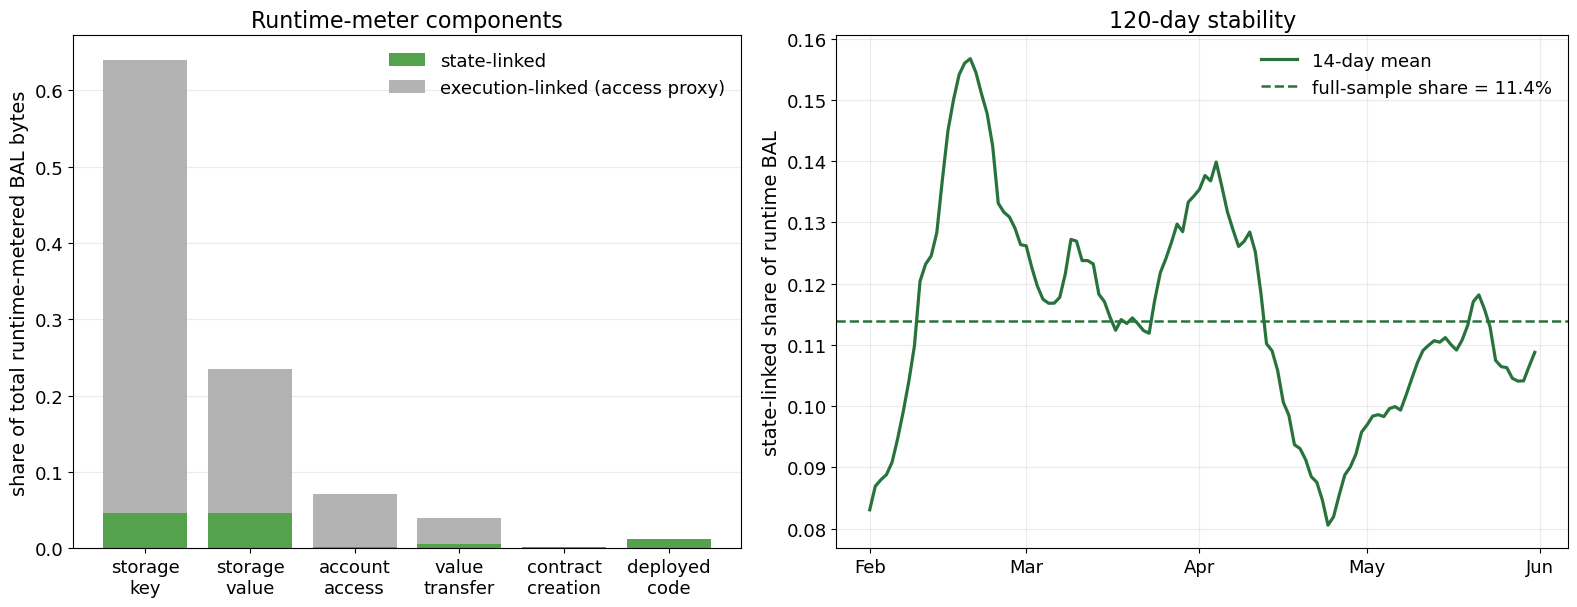

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.3), gridspec_kw={'width_ratios': [1.05, 1.15]})
x = np.arange(len(components))
state_share = components['state_bytes'] / TOTAL_RUNTIME_BYTES
execution_share = components['execution_bytes'] / TOTAL_RUNTIME_BYTES
axes[0].bar(x, state_share, color='#54a24b', label='state-linked')
axes[0].bar(
    x, execution_share, bottom=state_share, color='#b3b3b3',
    label='execution-linked (access proxy)',
)
axes[0].set_xticks(x, ['storage\nkey', 'storage\nvalue', 'account\naccess', 'value\ntransfer', 'contract\ncreation', 'deployed\ncode'])
axes[0].set_ylabel('share of total runtime-metered BAL bytes')
axes[0].set_title('Runtime-meter components')
axes[0].legend(frameon=False, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)

daily_plot = daily_attribution.copy()
daily_plot['date'] = pd.to_datetime(daily_plot['date'])
rolling_state = daily_plot.set_index('date')['state_weight'].rolling(
    14, center=True, min_periods=7
).mean()
axes[1].plot(rolling_state.index, rolling_state, color='#28733c', linewidth=2.3, label='14-day mean')
axes[1].axhline(
    STATE_WEIGHT, color='#28733c', linestyle='--', linewidth=1.8,
    label=f'full-sample share = {STATE_WEIGHT:.1%}',
)
axes[1].set_ylabel('state-linked share of runtime BAL')
axes[1].set_title('120-day stability')
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(COUPLING_PLOT, dpi=220, bbox_inches='tight')
plt.show()

## Central BAL demand model

Let $B_t$ denote EIP-8279 runtime-metered BAL bytes, $S_t$ persistent state-creation activity, and $A_t$ existing-state access activity. Define $w_{\mathrm{state}}$ and $w_{\mathrm{execution}}=1-w_{\mathrm{state}}$ as the two runtime-meter weights. The central model is

$$
\frac{B_t}{B_0}
=w_{\mathrm{state}}\frac{S_t}{S_0}
+w_{\mathrm{execution}}\frac{A_t}{A_0}.
$$

The 6,000-block estimates are $w_{\mathrm{state}}=0.113932$ and $w_{\mathrm{execution}}=0.886068$.

The wider historical panel does not contain an independently priced state-access quantity. Total execution activity is therefore used as a proxy:

$$
\frac{A_t}{A_0}
\approx
\left(\frac{E_t}{E_0}\right)^{\rho_A},
\qquad \rho_A=1.
$$

The central benchmark is therefore

$$
\frac{B_t}{B_0}
=0.113932\frac{S_t}{S_0}
+0.886068\frac{E_t}{E_0}.
$$

The execution-linked component is not empirically shown to follow execution demand. Total execution is a reduced-form proxy for state-access activity, and $\rho_A=1$ assumes that access intensity remains constant as execution scales.

The model also sets $\gamma_{\mathrm{BAL}}=0$. BAL responds through its parent state-creation and access activities rather than through an additional direct response to the data fee. This is an assumption for the current aggregate model, not an estimated zero elasticity.

In [9]:
GAMMA_BAL_CENTRAL = 0.0
RHO_ACCESS_CENTRAL = 1.0
central_model = pd.DataFrame([{
    'state_weight': STATE_WEIGHT,
    'execution_weight': EXECUTION_WEIGHT,
    'gamma_bal_data_price': GAMMA_BAL_CENTRAL,
    'rho_access_execution_proxy': RHO_ACCESS_CENTRAL,
}])
central_model

,state_weight,execution_weight,gamma_bal_data_price,rho_access_execution_proxy
0,0.113932,0.886068,0.0,1.0


## Appendix: Transaction-cost exposure diagnostic

At normalized anchor prices, each BAL-producing transaction's execution, data, and state cost shares are weighted by its EIP-8279 runtime bytes. The aggregate exposure is consistent with low additional state coupling beyond the state-linked component because execution dominates the normalized cost of BAL-producing transactions. Cost shares do not identify transaction exit elasticities and are not used to set the central BAL-demand coefficients. Transaction-level access-list, authorization, and blob-hash fields are unavailable in the joined panel and are omitted from this diagnostic.


In [10]:
COST_RESOURCES = ['execution', 'data', 'state']
bal_weights = tx_cost_panel['bal_runtime_bytes_8279'].to_numpy(dtype=float)
COST_RUNTIME_BYTES = float(bal_weights.sum())
exposure_rows = []
for resource in COST_RESOURCES:
    cost_share = tx_cost_panel[f'{resource}_composite_cost_share'].to_numpy(dtype=float)
    exposure_rows.append({
        'resource': resource,
        'bal_weighted_cost_exposure': float(np.dot(bal_weights, cost_share) / COST_RUNTIME_BYTES),
    })
exposure = pd.DataFrame(exposure_rows)
exposure.to_csv(OUT_EXPOSURE_CSV, index=False)
exposure


,resource,bal_weighted_cost_exposure
0,execution,0.801991
1,data,0.078105
2,state,0.119904


In [11]:
WHOLE_KAPPA = exposure.set_index('resource')['bal_weighted_cost_exposure'].to_dict()
state_proxy_cap_rows = int((
    tx_cost_panel['historical_state_creation_gas'] > tx_cost_panel['state_reference_gas_capped']
).sum())
state_proxy_cap_deficit = (
    tx_cost_panel['historical_state_creation_gas'] - tx_cost_panel['state_reference_gas_capped']
).clip(lower=0).sum()
state_proxy_cap_deficit_share = state_proxy_cap_deficit / tx_cost_panel['receipt_gas_used'].sum()

card = pd.DataFrame([{
    'runtime_meter_spec': 'EIP-8279 bal_data_bytes reconstructed from Xatu protocol events',
    'runtime_anchor_blocks': len(runtime_blocks),
    'runtime_transaction_attribution_blocks': len(attribution_blocks),
    'runtime_cost_diagnostic_blocks': tx_runtime['block_number'].nunique(),
    'runtime_block_transaction_exact_match_share': validation['difference'].eq(0).mean(),
    'bal_runtime_bytes_per_block_8279': RUNTIME_ANCHOR,
    'bal_runtime_data_gas_per_block_at_16': RUNTIME_DATA_GAS_16,
    'physical_bal_comparison_blocks': len(exact_bal_comparison),
    'bal_rlp_to_runtime_ratio': BAL_PHYSICAL_TO_RUNTIME_RATIO,
    'bal_rlp_minus_runtime_bytes_per_block': BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK,
    'bal_adjusted_content_mb_at_90m_sample_mean_bal': physical_comparison.loc[0, 'bal_adjusted_content_mb_at_90m_sample_mean_bal'],
    'state_linked_runtime_weight_8279': STATE_WEIGHT,
    'execution_linked_runtime_weight_8279': EXECUTION_WEIGHT,
    'whole_bal_kappa_execution': WHOLE_KAPPA['execution'],
    'whole_bal_kappa_data': WHOLE_KAPPA['data'],
    'whole_bal_kappa_state': WHOLE_KAPPA['state'],
    'central_gamma_bal_data_price': GAMMA_BAL_CENTRAL,
    'central_rho_access_execution_proxy': RHO_ACCESS_CENTRAL,
    'central_effective_state_weight': STATE_WEIGHT,
    'central_effective_execution_weight': EXECUTION_WEIGHT,
    'state_proxy_capped_transactions': state_proxy_cap_rows,
    'state_proxy_cap_deficit_share_receipt_gas': state_proxy_cap_deficit_share,
    'state_attribution_status': tx_runtime['direct_state_attribution_status'].iloc[0],
    'composite_cost_proxy_status': tx_cost_panel['composite_cost_proxy_status'].iloc[0],
    'meter_reconstruction_status': 'Xatu observed path; reverted-frame storage-value bytes unavailable',
}])
card.to_csv(OUT_CARD_CSV, index=False)

assert np.isclose(STATE_WEIGHT + EXECUTION_WEIGHT, 1.0)
assert 0.10 < STATE_WEIGHT < 0.14
assert np.isclose(sum(WHOLE_KAPPA.values()), 1.0)
assert GAMMA_BAL_CENTRAL == 0
assert RHO_ACCESS_CENTRAL == 1
assert 115_000 < RUNTIME_ANCHOR < 125_000
assert 1.05 < BAL_PHYSICAL_TO_RUNTIME_RATIO < 1.20
assert 10_000 < BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK < 20_000
assert runtime_blocks['bal_runtime_bytes_8279'].ge(0).all()

display(card.T)
print(OUT_DAILY_CSV)
print(OUT_COMPONENTS_CSV)
print(OUT_TWO_WAY_CSV)
print(OUT_EXPOSURE_CSV)
print(OUT_PHYSICAL_COMPARISON_CSV)
print(OUT_CARD_CSV)
print(COUPLING_PLOT)
print(DATA_COMPONENT_PLOT)

,0
runtime_meter_spec,EIP-8279 bal_data_bytes reconstructed from Xat...
runtime_anchor_blocks,6000
runtime_transaction_attribution_blocks,6000
runtime_cost_diagnostic_blocks,1200
runtime_block_transaction_exact_match_share,1.0
bal_runtime_bytes_per_block_8279,119943.743249
bal_runtime_data_gas_per_block_at_16,1919099.891982
physical_bal_comparison_blocks,1200
bal_rlp_to_runtime_ratio,1.108097
bal_rlp_minus_runtime_bytes_per_block,13080.413333


/Users/william/PycharmProjects/eip-7999-research/data/calibration_bal_runtime_8279_daily_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_component_attribution_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_two_way_decomposition_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_composite_cost_exposure_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_physical_comparison_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_parameter_card_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/plots/bal_state_creation_coupling_calibration_2026-02-01_2026-06-01.png
/Users/william/PycharmProjects/eip-7999-research/plots/daily_data_resource_components_runtime_8279_2026-02-01_2026-06-01.png
